

# MEEP: Half-Wave Dipole

A half-wave dipole is an elementary type of resonant antenna. For the simulation of the electromagnetic field radiated by the dipole, we will choose a 2D simulation environment with dimensions of 200 x 200 nodes. We will set the wavelength **λ** to 100 nodes; the half-wave dipole will then have a length of **50 nodes** and will be oriented in the direction of the Y-axis. The configuration of the dipole and the position of the source are shown in the image.

<img src="./img/dipol.png" width="200px" alt="Half-wave dipole, dimensions, and materials"/>

*Caption: Half-wave dipole, dimensions, and materials*

---

For excitation, we will use a source with the **E_Y component** of the electromagnetic field. In the normalized environment (where c=1), the frequency of the harmonic signal exciting the dipole will be:

$$
f = \frac{c}{\lambda} = \frac{1} {100} = 0.01
$$

The period of the harmonic signal in normalized time units will be:

$$
T = \frac{1}{f} = 100
$$

---

The material of the dipole is a **metal** (Perfect Electrical Conductor, modeled with $\epsilon_r = \infty$). The source is placed in the center, in the gap between the dipole's arms, within a **conductive medium** with a conductivity of $\sigma_D = 0.05$.

In [1]:

%matplotlib inline
import meep as mp 
import numpy as np
import matplotlib.pyplot as plt

f = 0.01                              # frekvencia zdroja
area = mp.Vector3(200,200,0)          # simulacne prostredie

dip = [mp.Block(mp.Vector3(1, 24),    # geometria dipolu
        center=mp.Vector3(0,12),
        material=mp.metal),

        mp.Block(mp.Vector3(1, 24),
        center=mp.Vector3(0,-12),
        material=mp.metal),

        mp.Block(mp.Vector3(1, 2),
        center=mp.Vector3(0, 0),
        material=mp.Medium( D_conductivity=0.05))
        ]

src = [mp.Source(mp.ContinuousSource(frequency=f),
        component=mp.Ey,
        center=mp.Vector3(0, 0,0)),    # zdroj
        ]

sim = mp.Simulation(cell_size=area, boundary_layers=[mp.PML(2.0)],
                    geometry=dip, sources=src, resolution=2)

sim.run(until=230)                     # simulacia cez 2*T

-----------
Initializing structure...
time for choose_chunkdivision = 8.01086e-05 s
Working in 2D dimensions.
Computational cell is 200 x 200 x 0 with resolution 2
     block, center = (0,12,0)
          size (1,24,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (0,-12,0)
          size (1,24,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (0,0,0)
          size (1,2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0649052 s
time for set_conductivity = 0.00261402 s
time for set_conductivity = 0.00251412 s
time for set_conductivity = 0.00255704 s
-----------


FloatProgress(value=0.0, description='0% done ', max=230.0)

run 0 finished at t = 230.0 (920 timesteps)




To display the component of the electric and magnetic field and the radiated power, we will use the `imshow()` method from the **matplotlib** library.

## Visualizing Simulation Data with `imshow`

To visualize the 2D data from the MEEP simulation (like the strength of the electric field across the grid), we will use the `imshow()` method from the **matplotlib** library. This function is ideal for creating a color-coded map of the field's intensity.

---

### Why Use `imshow`?

At any given moment, the result of a 2D simulation is essentially a large grid (a 2D array or matrix) of numbers. Each number in the grid represents the field's amplitude at that specific point in space. While you could look at the raw numbers, it's not very intuitive.

The `imshow()` function (which stands for "image show") solves this by translating that grid of numbers into a visual image. 🖼️ It assigns a specific color to each number based on its value, creating a heatmap.

* **High field values** might be colored red or yellow.
* **Low field values** might be colored blue or purple.
* **Zero field values** are often black or green.

This immediately gives you an intuitive understanding of the simulation, allowing you to see the wavefronts, radiation patterns, and interference effects.



---

### How It Works in Code

The process is generally straightforward:

1.  **Get the Data:** After running the simulation, you retrieve the 2D array of data you want to plot (e.g., the $E_z$ component).
2.  **Call `imshow`:** You pass this data array to the `plt.imshow()` function.
3.  **Customize (Optional):** You can add titles, color bars, and labels to make the plot clear and informative.
4.  **Display:** Finally, you call `plt.show()` to display the generated image.

Here's a conceptual example:

```python
# Assume 'ez_data' is a 2D NumPy array from the MEEP simulation
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(ez_data, cmap='RdBu') # Use the Red-Blue colormap
plt.colorbar(label="Electric Field (Ez)")
plt.title("Field at t = 200")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

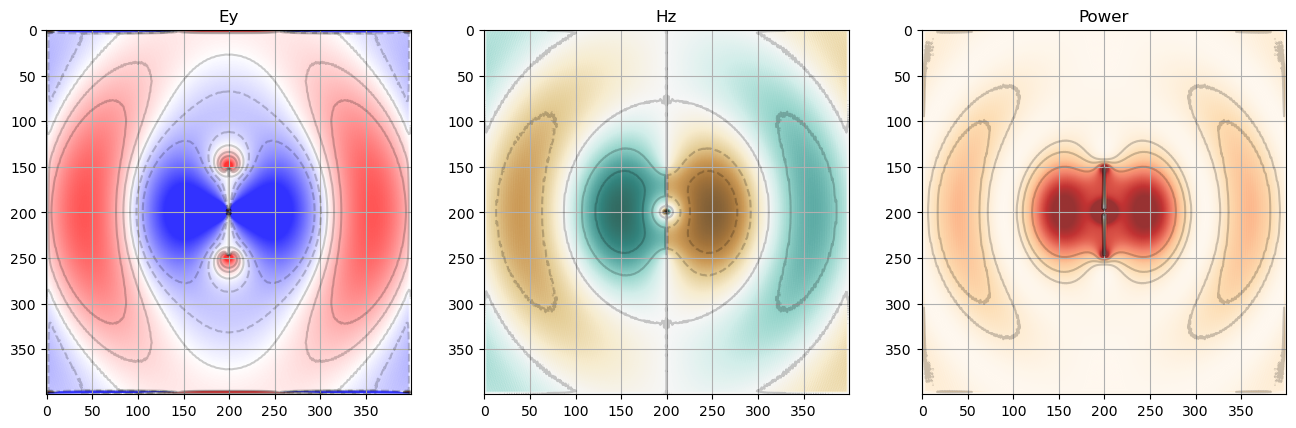

In [2]:
eps = sim.get_array(center=mp.Vector3(), size=area, component=mp.Dielectric)

pw = sim.get_array(center=mp.Vector3(), size=area, component=mp.EnergyDensity)
ey = sim.get_array(center=mp.Vector3(), size=area, component=mp.Ey)
hz = sim.get_array(center=mp.Vector3(), size=area, component=mp.Hz)

fig = plt.figure(dpi=100, figsize=(16,8))
ax = fig.add_subplot(131)
ax.imshow(ey.transpose(), interpolation='spline36', cmap='bwr', alpha=1.0,norm=plt.Normalize(-0.05, 0.05))
ax.contour(ey.transpose(), levels=[-0.02, -0.01, 0.0, 0.01, 0.02], colors="k", alpha=0.2)
ax.imshow(eps.transpose(), interpolation='spline36', cmap='gray', alpha=0.2)
ax.grid()
ax.set_title('Ey')

ax = fig.add_subplot(132)
ax.imshow(hz.transpose(), interpolation='spline36', cmap='BrBG', alpha=1.0, norm=plt.Normalize(-0.07, 0.07))
ax.imshow(eps.transpose(), interpolation='spline36', cmap='gray', alpha=0.2)
ax.contour(hz.transpose(), levels=[-0.05, -0.03, 0.0, 0.03, 0.05], colors="k", alpha=0.2)
ax.set_title('Hz')
ax.grid()

ax = fig.add_subplot(133)
ax.imshow(pw.transpose(), interpolation='spline36', cmap='OrRd', alpha=1.0,norm=plt.Normalize(-0.000, 0.004))
ax.imshow(eps.transpose(), interpolation='spline36', cmap='gray', alpha=0.2)
plt.contour(pw.transpose(), levels=[0.0005, 0.001, 0.002], colors="k", alpha=0.2)
ax.grid()
ax.set_title('Power')
plt.show()